In [1]:
from load_hollywood_heads import *
import os
import torch
import cv2
import numpy as np
import xml.etree.ElementTree as ET
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms


Loaded training dataset with 640 samples
Loaded validation dataset with 160 samples
随机选择的样本索引: [109 638]
Sample 1 (Dataset index: 109):


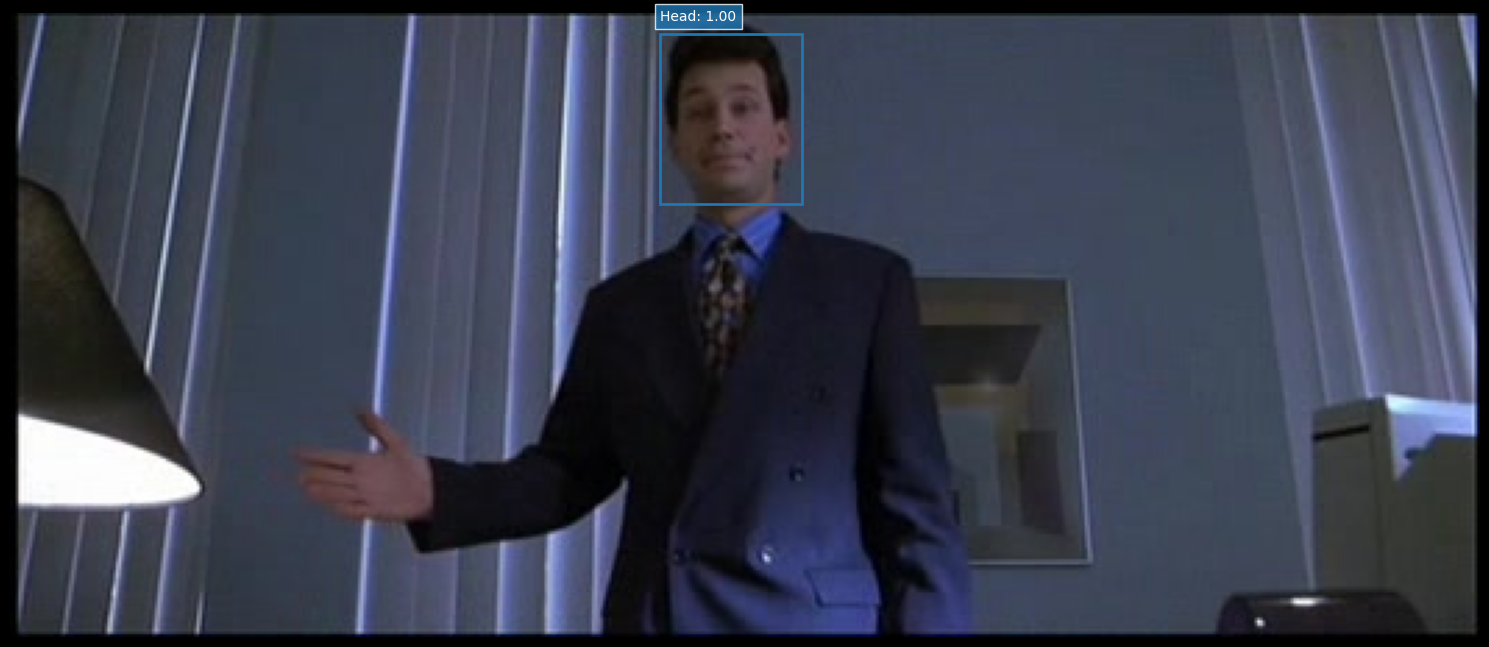

Sample 2 (Dataset index: 638):


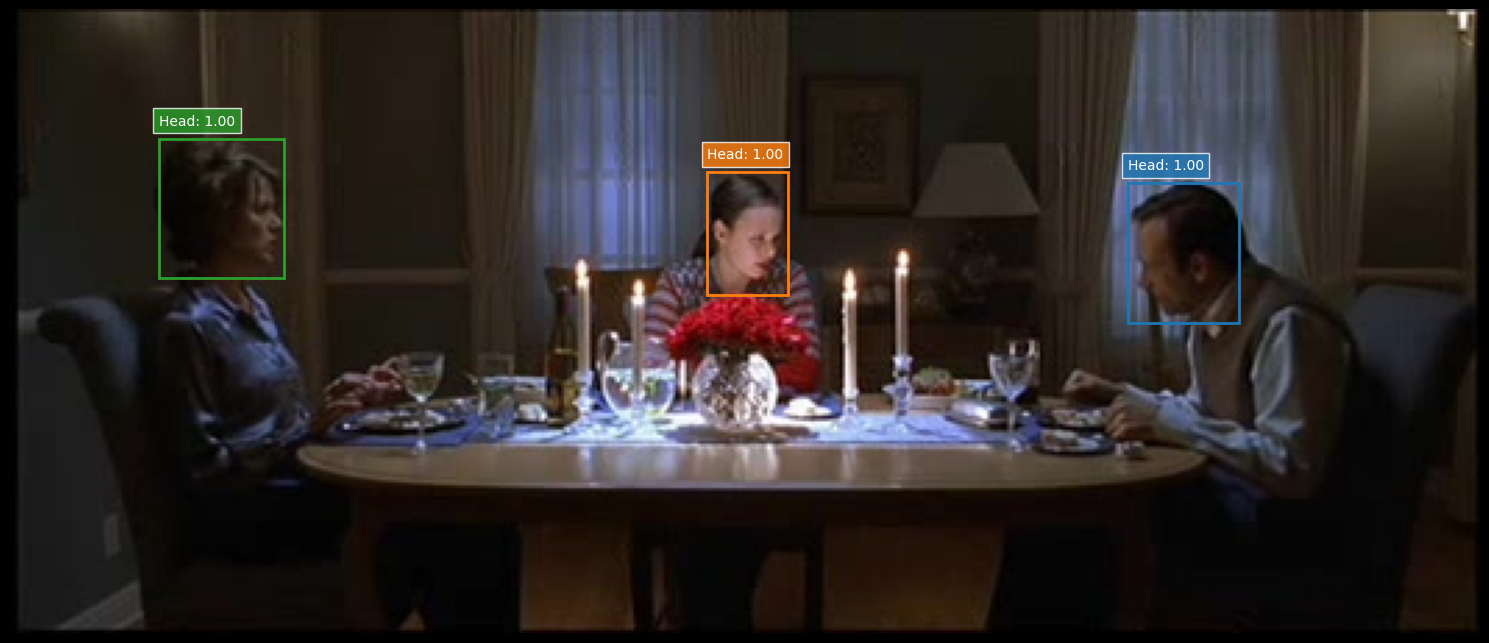

In [2]:

train_dataset, train_loader, val_dataset, val_loader = create_dataloaders(root_dir="HollywoodHeads", train_batch_size=16, max_samples=800);

# 可视化训练集的前5个样本
visualize_dataset_samples(train_dataset, num_samples=2)


In [3]:
# 设置设备
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Using device: {device}")



Using device: cuda


In [4]:
import torch
import torchvision
from torchvision.models.detection import retinanet_resnet50_fpn_v2, RetinaNet_ResNet50_FPN_V2_Weights

# 创建 RetinaNet 模型
def get_model(num_classes=2):  # 1类(头部) + 背景类
    # 加载预训练权重
    # weights = RetinaNet_ResNet50_FPN_V2_Weights.DEFAULT
    # model = retinanet_resnet50_fpn_v2(weights=weights)
    
    # # # 修改预测头使其适应我们的类别数
    # in_features = 256
    # num_anchors = model.head.classification_head.num_anchors
    # model.head.classification_head.num_classes = num_classes
    # model.head.classification_head.conv = torch.nn.Sequential(
    #     torch.nn.Conv2d(in_features, in_features, kernel_size=3, stride=1, padding=1),
    #     torch.nn.ReLU(),
    #     torch.nn.Conv2d(in_features, num_anchors * num_classes, kernel_size=3, stride=1, padding=1)
    # )
    
    # return model
    # 适用于较新版本的torchvision
    model = torchvision.models.detection.retinanet_resnet50_fpn(
        weights=None,  # 不使用预训练权重
        num_classes=num_classes,
        weights_backbone=torchvision.models.ResNet50_Weights.IMAGENET1K_V1  # 使用预训练骨干
    )

    for param in model.backbone.parameters():
        param.requires_grad = False

    return model


# 训练一个 epoch
def train_one_epoch(model, optimizer, data_loader, device):
    model.train()
    total_loss = 0
    
    for images, targets in data_loader:
        images = [image.to(device) for image in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        
        # 清除梯度
        optimizer.zero_grad()
        
        # 前向传播
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        
        # 反向传播和优化
        losses.backward()
        optimizer.step()
        
        total_loss += losses.item()
    
    return total_loss / len(data_loader)


from torchvision.utils import draw_bounding_boxes
import torchvision.transforms.functional as F

def evaluate(model, data_loader, device, iou_threshold=0.5):
    model.eval()
    total_loss = 0
    all_detections = []
    all_targets = []
    
    with torch.no_grad():
        for images, targets in data_loader:
            images = [image.to(device) for image in images]
            
            # # 前向传播 - 获取预测结果
            # predictions = model(images)
            
            # # 收集预测和目标以便计算指标
            # for pred, target in zip(predictions, targets):
            #     # 过滤低置信度预测
            #     keep = pred['scores'] > 0.5
            #     filtered_pred = {
            #         'boxes': pred['boxes'][keep].cpu(),
            #         'labels': pred['labels'][keep].cpu(),
            #         'scores': pred['scores'][keep].cpu()
            #     }
                
            #     all_detections.append(filtered_pred)
            #     all_targets.append({
            #         'boxes': target['boxes'].cpu(),
            #         'labels': target['labels'].cpu()
            #     })
            
            # 为了获取损失，我们需要临时设置训练模式
            model.train()
            targets_on_device = [{k: v.to(device) for k, v in t.items()} for t in targets]
            loss_dict = model(images, targets_on_device)
            model.eval()
            
            losses = sum(loss for loss in loss_dict.values())
            total_loss += losses.item()
    
    # 计算平均损失
    avg_loss = total_loss / max(1, len(data_loader))
    
    # 可以在这里添加mAP计算（需要额外的代码）
    
    return avg_loss

# 实现主训练循环
def train_model(num_epochs=10, lr=5e-5):
    # 获取数据加载器和数据集

    print(f"训练集样本数: {len(train_dataset)}, 验证集样本数: {len(val_dataset)}")
    
    # 创建模型
    model = get_model(num_classes=2)  # 1类(头部) + 背景类
    model.to(device)
    
    # 定义优化器
    # 使用更稳健的训练参数
    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr,  # 使用非常小的学习率
        weight_decay=1e-4
    )

    # 使用更平滑的学习率调度
    lr_scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, 
        max_lr=1e-4,
        steps_per_epoch=len(train_loader),
        epochs=num_epochs
)
    #  # 学习率调度器
    # lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)
    
    # 训练循环
    for epoch in range(num_epochs):
        # 训练一个 epoch
        train_loss = train_one_epoch(model, optimizer, train_loader, device)
        
        # 更新学习率
        lr_scheduler.step()
        
        # 在验证集上评估
        val_loss = evaluate(model, val_loader, device)
        
        # 打印进度
        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
    
    return model
    

# 推理函数
def predict(model, dataset, idx, threshold=0.5, device=device):
    # 切换到评估模式
    model.eval()
    
    # 获取图像
    image, _ = dataset[idx]
    
    # 移动到设备上
    image = image.unsqueeze(0).to(device)
    
    # 推理
    with torch.no_grad():
        prediction = model(image)[0]
    
    # 获取高于阈值的预测
    keep = prediction['scores'] > threshold
    boxes = prediction['boxes'][keep].cpu().numpy()
    scores = prediction['scores'][keep].cpu().numpy()
    labels = prediction['labels'][keep].cpu().numpy()

     # 获取原始图像用于可视化
    orig_image, _ = dataset.get_raw_sample(idx)
    
    # 类别名称
    class_names = [f"Head" for _ in labels]
    
    # 可视化
    from load_hollywood_heads import visualize_detections
    visualize_detections(orig_image, boxes, class_names, scores)
    
    return prediction
    

In [5]:

    # 训练模型
    model = train_model(num_epochs=100)
    
    # 保存模型
    torch.save(model.state_dict(), "hollywood_heads_retinanet.pth")
    
    
    # # 预测和可视化
    # sample_idx = 0  # 可以更换为任意样本索引
    # predict(model, val_dataset, sample_idx, threshold=0.5)

训练集样本数: 640, 验证集样本数: 160
Epoch 1/100, Train Loss: 1.7376, Val Loss: 1.6857
Epoch 2/100, Train Loss: 1.5572, Val Loss: 1.5167
Epoch 3/100, Train Loss: 1.2546, Val Loss: 1.2536
Epoch 4/100, Train Loss: 1.0705, Val Loss: 1.2747
Epoch 5/100, Train Loss: 0.9882, Val Loss: 1.2575
Epoch 6/100, Train Loss: 0.9145, Val Loss: 1.2318
Epoch 7/100, Train Loss: 0.8338, Val Loss: 1.2084
Epoch 8/100, Train Loss: 0.7821, Val Loss: 1.2486
Epoch 9/100, Train Loss: 0.7234, Val Loss: 1.2220
Epoch 10/100, Train Loss: 0.6846, Val Loss: 1.1870
Epoch 11/100, Train Loss: 0.6512, Val Loss: 1.1628
Epoch 12/100, Train Loss: 0.6171, Val Loss: 1.1039
Epoch 13/100, Train Loss: 0.5935, Val Loss: 1.0821
Epoch 14/100, Train Loss: 0.5722, Val Loss: 1.0982
Epoch 15/100, Train Loss: 0.5421, Val Loss: 1.0601
Epoch 16/100, Train Loss: 0.5340, Val Loss: 1.0556
Epoch 17/100, Train Loss: 0.5103, Val Loss: 1.0026
Epoch 18/100, Train Loss: 0.5054, Val Loss: 0.9821
Epoch 19/100, Train Loss: 0.4916, Val Loss: 0.9506
Epoch 20/100, T

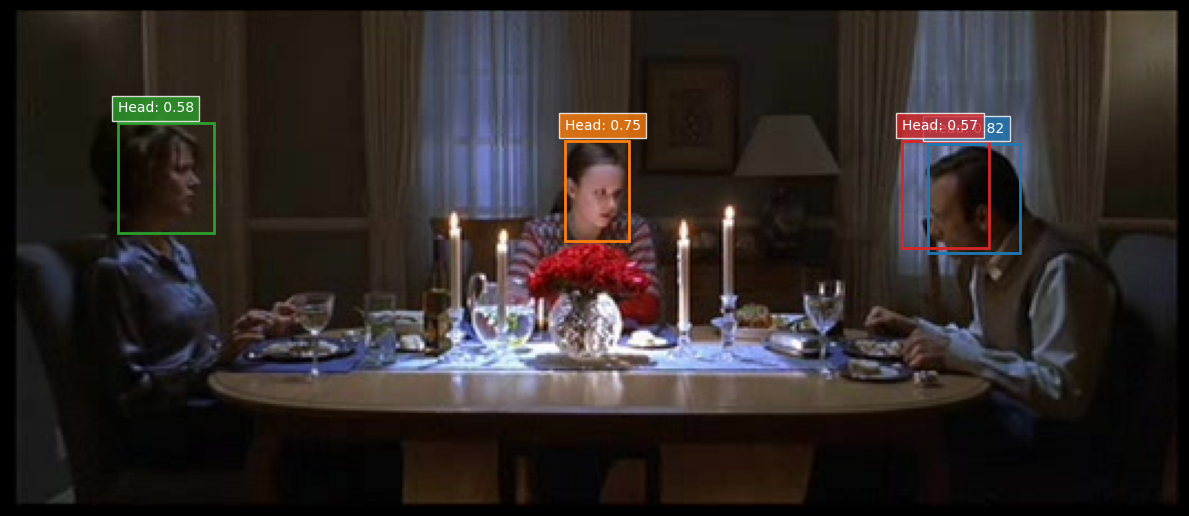

{'boxes': tensor([[413.8224,  59.9493, 455.1938, 109.2263],
         [249.7700,  58.7612, 278.9253, 103.8149],
         [ 48.1427,  50.7413,  91.4398, 100.2654],
         [402.0411,  58.7416, 441.4864, 107.2180],
         [ 40.7016,  40.1081,  85.2641,  89.3801],
         [423.0748,  65.6991, 467.2653, 115.3515],
         [389.7245,  55.3144, 429.0284, 101.6253],
         [412.4734,  81.3839, 457.3277, 136.5179],
         [ 59.9591,  40.4090, 101.7266,  89.1756],
         [249.2166,  51.1905, 297.7193,  99.5872],
         [389.4004,  69.8154, 429.4442, 118.3022],
         [402.4320,  46.6446, 463.5484, 119.1002],
         [144.3607,  43.9798, 186.1280,  94.7961],
         [ 35.7676,  59.1162,  78.6847, 108.6597],
         [ 48.0854,  25.7029,  90.9339,  75.0880],
         [ 49.2736,  68.3830,  89.9599, 117.4361],
         [ 67.9367,  84.7251, 108.9022, 133.9909],
         [ 67.0032,  51.9982, 108.1134, 100.4606],
         [149.0935,  31.9474, 192.4912,  80.9767],
         [396.3096,  8

In [17]:
    # 预测和可视化
    sample_idx = 120  # 可以更换为任意样本索引
    predict(model, val_dataset, sample_idx, threshold=0.5)

In [7]:
# weights = RetinaNet_ResNet50_FPN_V2_Weights.DEFAULT
# model = retinanet_resnet50_fpn_v2(weights=weights)
# print(model.head.classification_head.conv)